In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip
/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip
/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip
/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip


In [3]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [4]:
train = pd.read_csv('/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip')
test = pd.read_csv('/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip')
subm = pd.read_csv('/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip')

# 1. Data Understanding 

## Dataset shape

In [47]:
train.shape
train.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## Data types

In [48]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


## Missing values analysis 

In [49]:
train.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

## Duplicate samples check 

In [50]:
train.duplicated().sum()

np.int64(0)

## Basic statistics 

In [51]:
train.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 2. Target / Label Analysis 

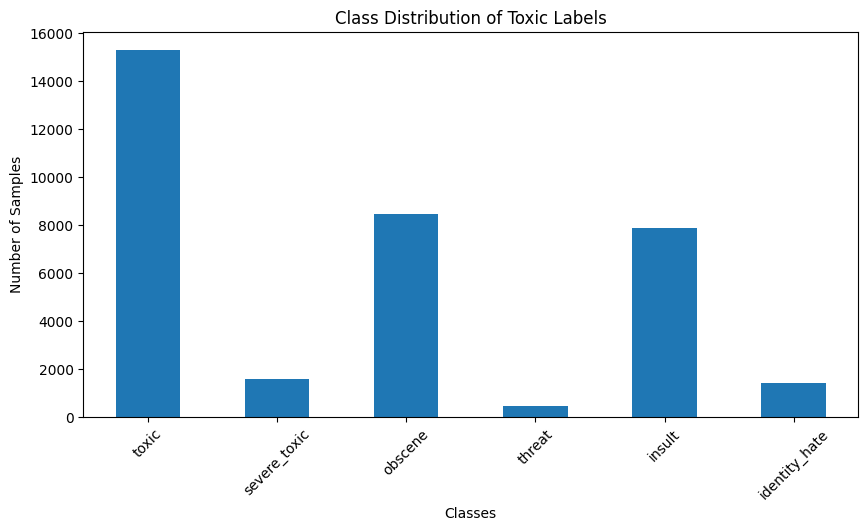

In [9]:
import matplotlib.pyplot as plt

labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
class_counts = train[labels].sum()


plt.figure(figsize=(10,5))
class_counts.plot(kind='bar')

plt.title("Class Distribution of Toxic Labels")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

# 3. Preprocessing

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove urls
    text = re.sub(r"[^a-zA-Z]", " ", text)  # remove punctuation
    tokens = text.split()
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

train['clean_text'] = train['comment_text'].apply(clean_text)

# 3. Feature Analysis 

##  Token length distribution  

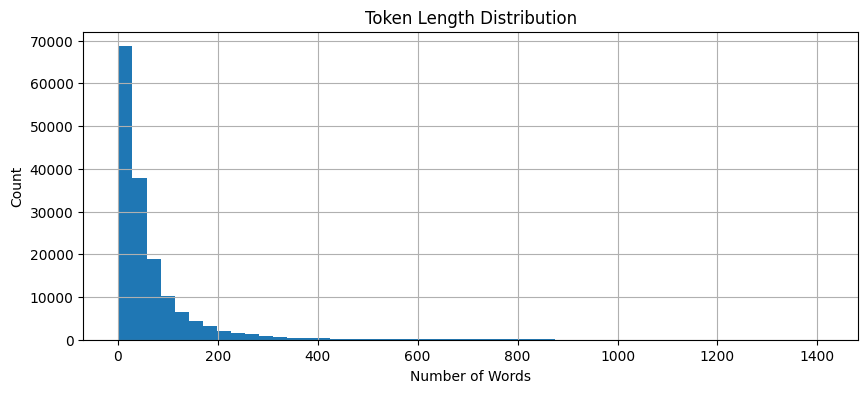

In [54]:
train['token_count'] = train['comment_text'].str.split().str.len()
train['token_count'].hist(bins=50, figsize=(10,4))
plt.title('Token Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

##  Most frequent words (top N) 

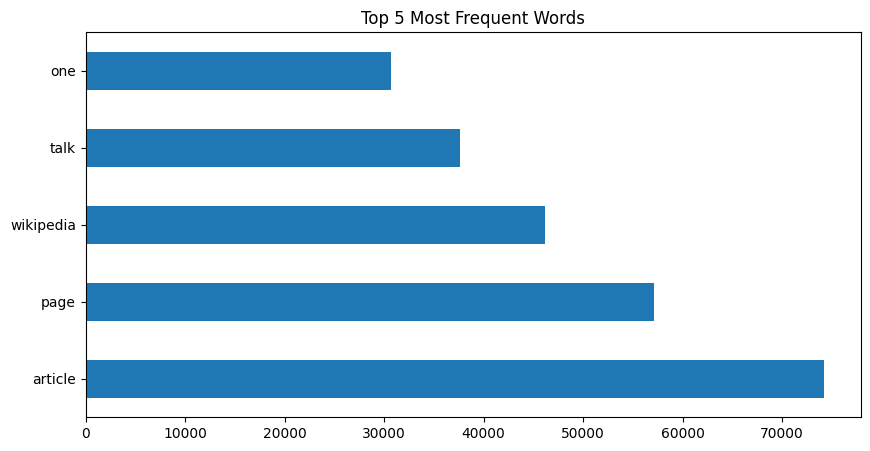

In [55]:
all_words = ' '.join(train['clean_text']).split()
word_freq = pd.Series(all_words).value_counts()[:5]

word_freq.plot(kind='barh', figsize=(10,5))
plt.title('Top 5 Most Frequent Words')
plt.show()

## Word cloud 

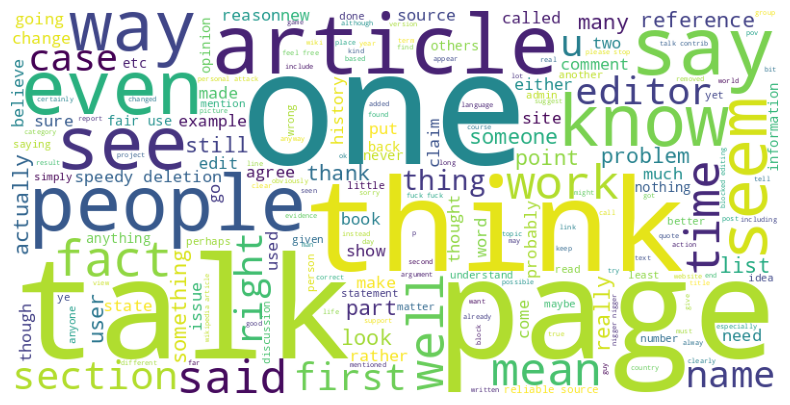

In [56]:
from wordcloud import WordCloud

text = ' '.join(train['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

##  N-grams analysis  


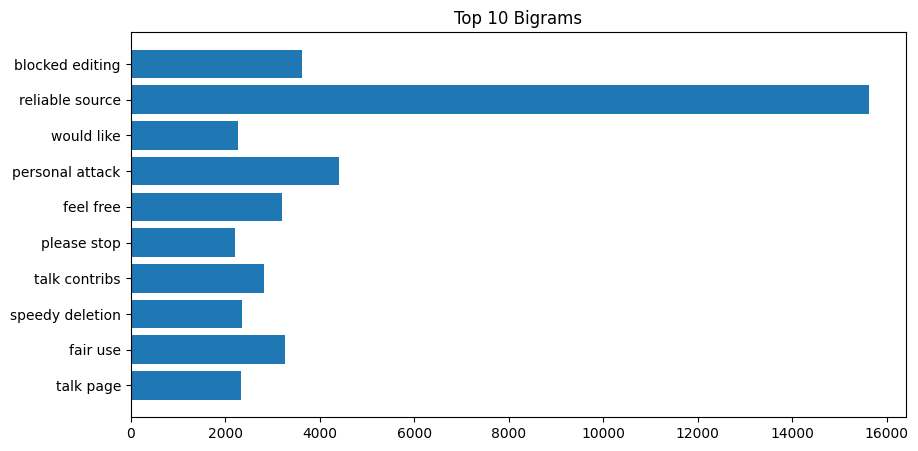

In [57]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams
vec = CountVectorizer(ngram_range=(2,2), max_features=10).fit(train['clean_text'])
counts = vec.transform(train['clean_text']).sum(axis=0).tolist()[0]
words = list(vec.vocabulary_.keys())

plt.figure(figsize=(10,5))
plt.barh(words, counts)
plt.title('Top 10 Bigrams')
plt.show()

# 4. Feature Engineering

## tfidf

In [6]:
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

threshold = 0.3



In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [10]:
# ===== TF-IDF =====
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(train['clean_text'])
y = train[labels]

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_tfidf = MultiOutputClassifier(
    CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000)
    )
)
model_tfidf.fit(X_train_tfidf, y_train)



MultiOutputClassifier(estimator=CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                                                           max_iter=5000)))

In [11]:
# Probabilities + Threshold
y_prob_tfidf = model_tfidf.predict_proba(X_test_tfidf)
y_pred_tfidf = np.array([
    (prob[:, 1] >= threshold).astype(int)
    for prob in y_prob_tfidf
]).T


##   BERT Embeddings

In [12]:
!pip install sentence-transformers

In [13]:
# ===== BERT =====
from sentence_transformers import SentenceTransformer
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

X_bert = bert_model.encode(
    train['clean_text'].tolist(),
    show_progress_bar=True,
    batch_size=128,
    device=device
)

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y, test_size=0.2, random_state=42
)

model_bert = MultiOutputClassifier(
    CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000)
    )
)
model_bert.fit(X_train_bert, y_train_bert)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1247 [00:00<?, ?it/s]

MultiOutputClassifier(estimator=CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                                                           max_iter=5000)))

In [14]:
# Probabilities + Threshold
y_prob_bert = model_bert.predict_proba(X_test_bert)
y_pred_bert = np.array([
    (prob[:, 1] >= threshold).astype(int)
    for prob in y_prob_bert
]).T


In [15]:
# ===== Evaluation =====
from sklearn.metrics import f1_score, accuracy_score

y_test_arr      = np.array(y_test).astype(int)
y_test_bert_arr = np.array(y_test_bert).astype(int)

f1_tfidf  = f1_score(y_test_arr, y_pred_tfidf, average='macro')
acc_tfidf = accuracy_score(y_test_arr, y_pred_tfidf)

f1_bert   = f1_score(y_test_bert_arr, y_pred_bert, average='macro')
acc_bert  = accuracy_score(y_test_bert_arr, y_pred_bert)

# ===== Comparison =====
comparison = pd.DataFrame({
    'Model'    : ['TF-IDF + LinearSVC', 'BERT + LinearSVC'],
    'F1-score' : [f1_tfidf, f1_bert],
    'Accuracy' : [acc_tfidf, acc_bert]
})

print(comparison)

                Model  F1-score  Accuracy
0  TF-IDF + LinearSVC  0.570554  0.910293
1    BERT + LinearSVC  0.536585  0.902178


# 5. models

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier


models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=200,
            class_weight='balanced'
        ),

    "SVM":
        LinearSVC(
            class_weight='balanced'
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            class_weight='balanced'
        ),

    "Random Forest":
        RandomForestClassifier(
            class_weight='balanced'
        ),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=100,
            random_state=42
        )
}

In [22]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

results = []

for name, model in models.items():

    multi_model = MultiOutputClassifier(model)
    
    # Training
    multi_model.fit(X_train_tfidf, y_train)

    # Prediction
    y_pred = multi_model.predict(X_test_tfidf)

    # Evaluation
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "F1-score": f1,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1-score",
    ascending=False
)

,Model,F1-score,Accuracy
1,SVM,0.514042,0.855428
0,Logistic Regression,0.512951,0.862416
3,Random Forest,0.434832,0.908632
2,Decision Tree,0.408153,0.842112
4,AdaBoost,0.278702,0.904998


# 6. LLM

In [16]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.6 MB/s eta 0:00:00


In [17]:
from groq import Groq

client = Groq(api_key="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")

In [18]:
def explain(text, prediction):

    prompt = f"""
    Explain why this comment was classified as toxic.
    Comment:
    {text}
    Prediction:
    {prediction}
    Explain in simple words.
    """

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

In [19]:
comment = "i will kill you"
clean = clean_text(comment)
vec = tfidf.transform([clean])

y_prob = model_tfidf.predict_proba(vec)
prediction = np.array([
    (prob[:, 1] >= threshold).astype(int)
    for prob in y_prob
]).flatten()

pred_dict = {label: int(val) for label, val in zip(labels, prediction)}

print(pred_dict)
print(explain(comment, pred_dict))

{'toxic': 1, 'severe_toxic': 0, 'obscene': 0, 'threat': 1, 'insult': 0, 'identity_hate': 0}
This comment was classified as toxic because it contains a threat. 

In simple words, a threat is a statement that says something will be done to harm someone else, like saying "I'll kill you." This kind of language is not acceptable and can make people feel scared or upset. The model classified it as a threat because it's a clear warning of potential harm.


# 7. Gradio App

In [20]:
import gradio as gr

def predict(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])

 
    y_prob = model_tfidf.predict_proba(vec)
    pred = np.array([
        (prob[:, 1] >= threshold).astype(int)
        for prob in y_prob
    ]).flatten()

    result = {}
    for label, value in zip(labels, pred):
        result[label] = int(value)

    explanation = explain(text, result)

    return str(result), explanation


gr.Interface(
    fn=predict,
    inputs="text",
    outputs=["text", "text"]
).launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://9438506f2b34325220.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 8. Project Structure

In [ ]:
toxic-comment-classification/
│
├── data/
│   ├── raw/
│   │   ├── train.csv
│   │   ├── test.csv
│   │   └── test_labels.csv
│   │
│   └── processed/
│       ├── cleaned_data.csv
│       └── tfidf_features.pkl
│
├── notebooks/
│   ├── eda.ipynb
│   ├── preprocessing.ipynb
│   ├── model_training.ipynb
│   └── evaluation.ipynb
│
├── src/
│   ├── preprocessing.py
│   ├── text_analysis.py
│   ├── feature_engineering.py
│   ├── train_ml.py
│   ├── evaluate.py
│   ├── predict.py
│   └── utils.py
│
├── models/
│   ├── logistic_model.pkl
│   ├── svm_model.pkl
│   ├── random_forest.pkl
│   └── tfidf_vectorizer.pkl
│
├── reports/
│   ├── figures/
│   │   ├── class_distribution.png
│   │   ├── wordcloud.png
│   │   ├── confusion_matrix.png
│   │   └── model_comparison.png
│   │
│   └── final_report.pdf
│
├── app/
│   └── app_gradio.py
│
├── requirements.txt
├── README.md
└── .gitignore